<a href="https://colab.research.google.com/github/gyatun/clustering_university_students_by_spending/blob/main/Project2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
df = pd.read_csv("startup_funding.csv")
df.head()

,Sr No,Date dd/mm/yyyy,Startup Name,Industry Vertical,SubVertical,City Location,Investors Name,InvestmentnType,Amount in USD,Remarks
0,1,09/01/2020,BYJU’S,E-Tech,E-learning,Bengaluru,Tiger Global Management,Private Equity Round,"20,00,00,000",NaN
1,2,13/01/2020,Shuttl,Transportation,App based shuttle service,Gurgaon,Susquehanna Growth Equity,Series C,"80,48,394",NaN
2,3,09/01/2020,Mamaearth,E-commerce,Retailer of baby and toddler products,Bengaluru,Sequoia Capital India,Series B,"1,83,58,860",NaN
3,4,02/01/2020,https://www.wealthbucket.in/,FinTech,Online Investment,New Delhi,Vinod Khatumal,Pre-series A,"30,00,000",NaN
4,5,02/01/2020,Fashor,Fashion and Apparel,Embroiled Clothes For Women,Mumbai,Sprout Venture Partners,Seed Round,"18,00,000",NaN


In [ ]:
df.shape


(3044, 10)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3044 entries, 0 to 3043
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Sr No              3044 non-null   int64 
 1   Date dd/mm/yyyy    3044 non-null   object
 2   Startup Name       3044 non-null   object
 3   Industry Vertical  2873 non-null   object
 4   SubVertical        2108 non-null   object
 5   City  Location     2864 non-null   object
 6   Investors Name     3020 non-null   object
 7   InvestmentnType    3040 non-null   object
 8   Amount in USD      2084 non-null   object
 9   Remarks            419 non-null    object
dtypes: int64(1), object(9)
memory usage: 237.9+ KB


In [ ]:
#converting the amount in usd(object type to float type)
df['Amount in USD'] = df['Amount in USD'].astype(str)

df['Amount in USD'] = df['Amount in USD'].str.replace(',', '')

df['Amount in USD'] = pd.to_numeric(
    df['Amount in USD'],
    errors='coerce'
)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3044 entries, 0 to 3043
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Sr No              3044 non-null   int64  
 1   Date dd/mm/yyyy    3044 non-null   object 
 2   Startup Name       3044 non-null   object 
 3   Industry Vertical  2873 non-null   object 
 4   SubVertical        2108 non-null   object 
 5   City  Location     2864 non-null   object 
 6   Investors Name     3020 non-null   object 
 7   InvestmentnType    3040 non-null   object 
 8   Amount in USD      2065 non-null   float64
 9   Remarks            419 non-null    object 
dtypes: float64(1), int64(1), object(8)
memory usage: 237.9+ KB


In [ ]:
df.describe()

,Sr No,Amount in USD
count,3044.000000,2.065000e+03
mean,1522.500000,1.842990e+07
std,878.871435,1.213734e+08
min,1.000000,1.600000e+04
25%,761.750000,4.700000e+05
50%,1522.500000,1.700000e+06
75%,2283.250000,8.000000e+06
max,3044.000000,3.900000e+09


In [ ]:
#check missing-null values
missing = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Percentage': (df.isnull().sum()/len(df))*100
})

missing.sort_values(
    by='Percentage',
    ascending=False
)

,Missing Values,Percentage
Remarks,2625,86.235217
Amount in USD,979,32.161629
SubVertical,936,30.749014
City Location,180,5.913272
Industry Vertical,171,5.617608
Investors Name,24,0.788436
InvestmentnType,4,0.131406
Sr No,0,0.000000
Date dd/mm/yyyy,0,0.000000
Startup Name,0,0.000000


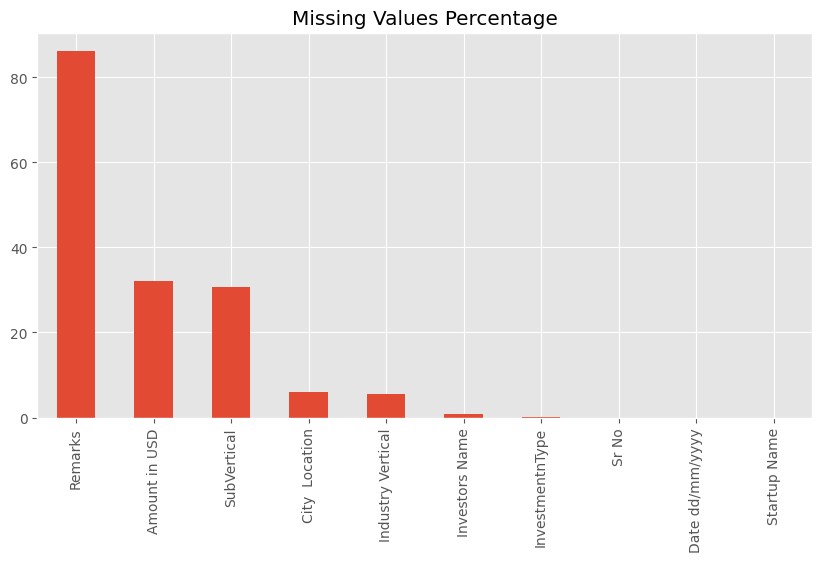

In [ ]:
plt.figure(figsize=(10,5))

(df.isnull().sum()/len(df)*100)\
.sort_values(ascending=False)\
.plot(kind='bar')

plt.title("Missing Values Percentage")
plt.show()

In [ ]:
#checking the duplicate
df.duplicated().sum()


np.int64(0)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.drop('Remarks',axis=1,inplace=True) #drop remarks column-->80% data are missing

In [ ]:
#rename columns
df.columns=[
'Serial_No',
'Date',
'Startup_Name',
'Industry',
'SubVertical',
'City',
'Investors',
'Funding_Type',
'Amount'
]

In [ ]:
#fill missing values

df['Industry'] = df['Industry'].fillna('Unknown')
df['SubVertical'] = df['SubVertical'].fillna('Unknown')
df['City'] = df['City'].fillna('Unknown')
df['Investors'] = df['Investors'].fillna('Unknown')
df['Funding_Type'] = df['Funding_Type'].fillna('Unknown')

In [ ]:
df.isnull().sum()

,0
Serial_No,0
Date,0
Startup_Name,0
Industry,0
SubVertical,0
City,0
Investors,0
Funding_Type,0
Amount,0


In [ ]:
#converts invalid date to valid date nT
df['Date'] = pd.to_datetime(
    df['Date'],
    dayfirst=True,
    errors='coerce'
)

df['Year'] = df['Date'].dt.year
df['Date'].isna().sum()

np.int64(8)

In [ ]:
#top cities with most startups
df['City'].value_counts().head(10)

,count
City,
Bangalore,700
Mumbai,567
New Delhi,421
Gurgaon,287
Unknown,180
Bengaluru,141
Pune,105
Hyderabad,99
Chennai,97


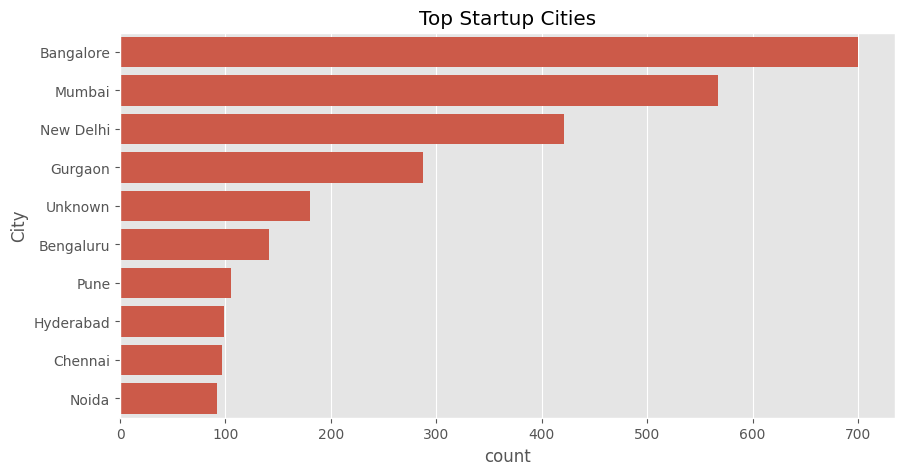

In [ ]:
#top cities with most startups- bar chart
plt.figure(figsize=(10,5))

sns.countplot(
y=df['City'],
order=df['City'].value_counts().head(10).index
)

plt.title("Top Startup Cities")
plt.show()

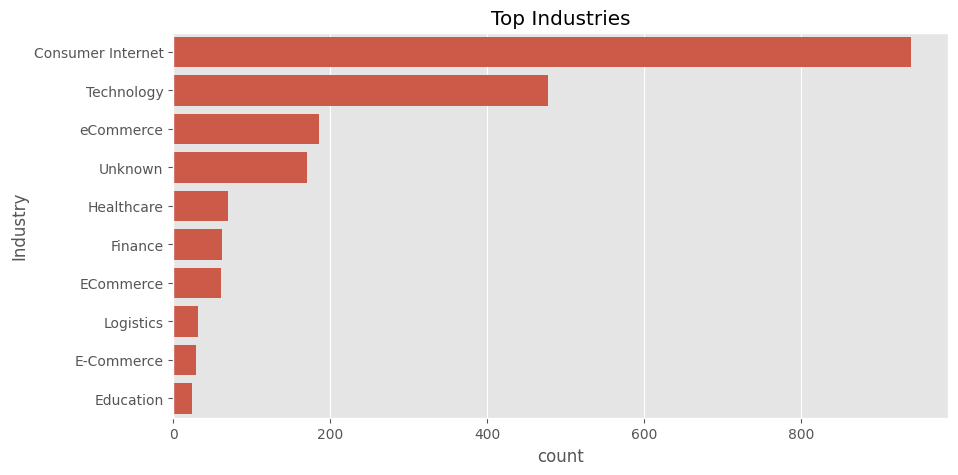

In [ ]:
#top industries
plt.figure(figsize=(10,5))

sns.countplot(
y=df['Industry'],
order=df['Industry'].value_counts().head(10).index
)

plt.title("Top Industries")
plt.show()

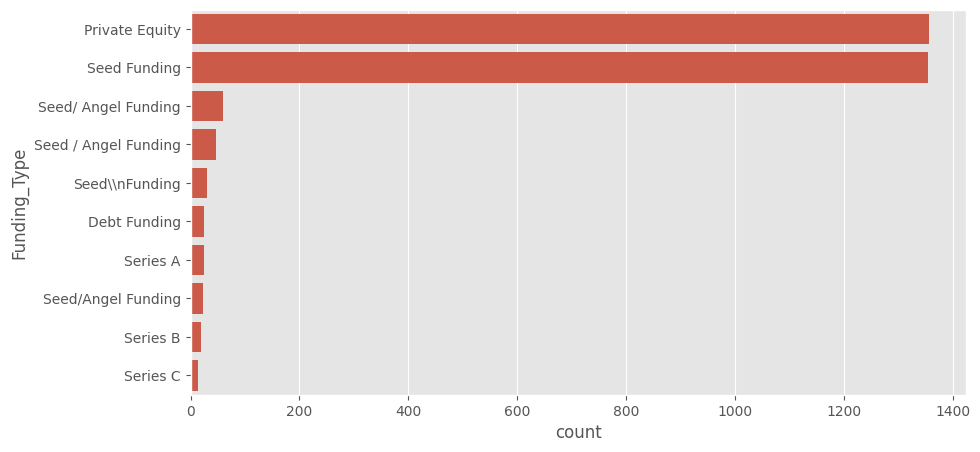

In [ ]:
#funding distribution
plt.figure(figsize=(10,5))

sns.countplot(
y=df['Funding_Type'],
order=df['Funding_Type'].value_counts().head(10).index
)

plt.show()

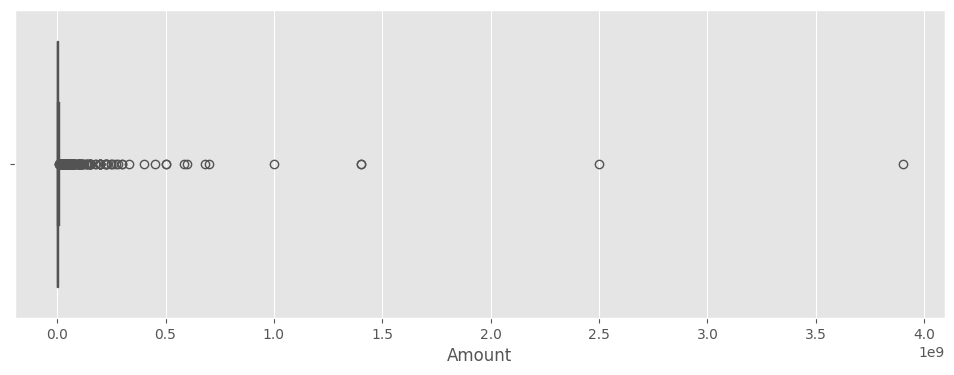

In [ ]:
#outliers detection
plt.figure(figsize=(12,4))

sns.boxplot(
x=df['Amount']
)

plt.show()
#boxplot--->>



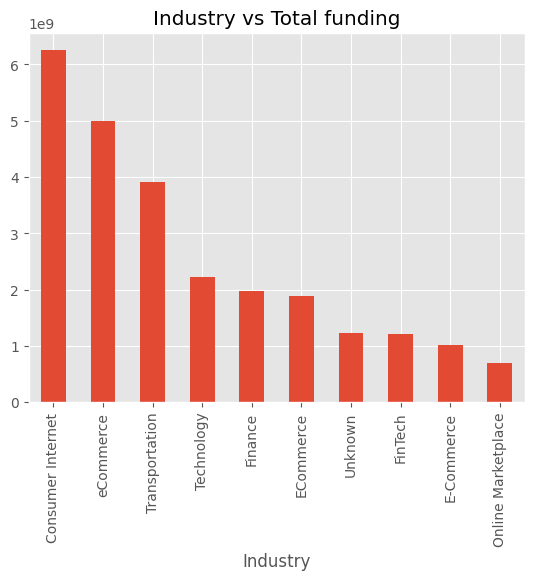

In [ ]:
#industry vs total funding
industry_funding=df.groupby(
'Industry'
)['Amount'].sum()

industry_funding\
.sort_values(ascending=False)\
.head(10)\
.plot(kind='bar')
plt.title("Industry vs Total funding")
plt.show()

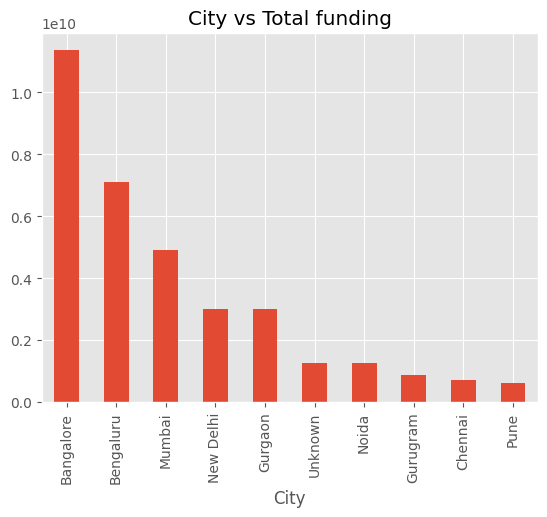

In [ ]:
#city vs total funding
city_funding=df.groupby(
'City'
)['Amount'].sum()

city_funding\
.sort_values(ascending=False)\
.head(10)\
.plot(kind='bar')
plt.title("City vs Total funding")
plt.show()

In [ ]:
##investor analysis--Top 10 investor
df['Investors']\
.value_counts()\
.head(10)

,count
Investors,
Undisclosed Investors,39
Undisclosed investors,30
Ratan Tata,25
Unknown,24
Indian Angel Network,23
Kalaari Capital,16
Group of Angel Investors,15
Sequoia Capital,15
Undisclosed Investor,12


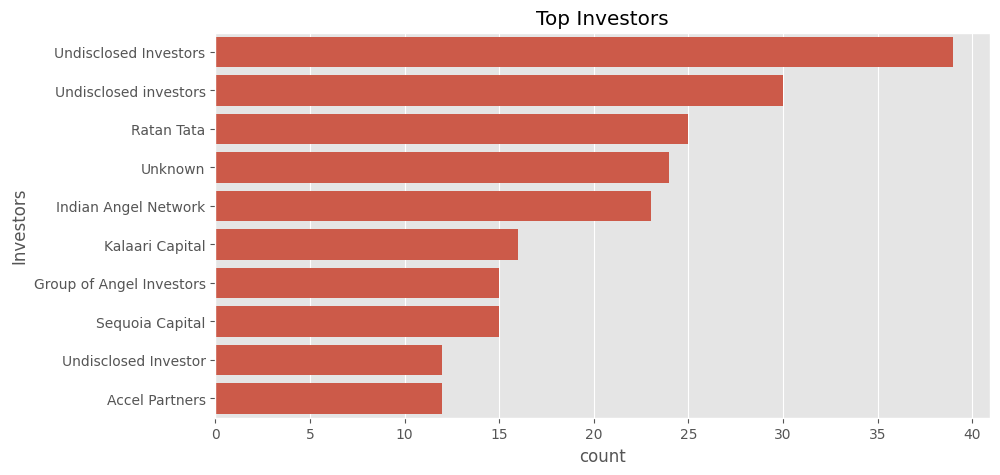

In [ ]:
plt.figure(figsize=(10,5))

sns.countplot(
y=df['Investors'],
order=df['Investors'].value_counts().head(10).index
)
plt.title("Top Investors")
plt.show()

In [ ]:
#time series analysis
yearly=df.groupby(
'Year'
)['Amount'].sum()

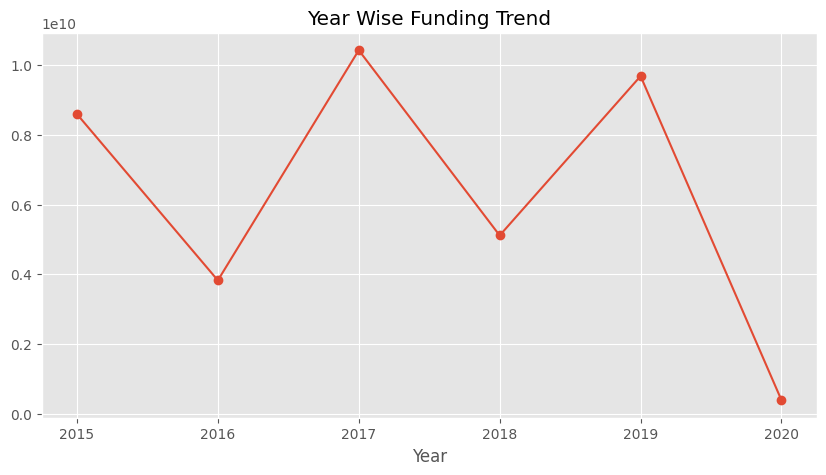

In [ ]:
plt.figure(figsize=(10,5))

yearly.plot(marker='o')

plt.title(
'Year Wise Funding Trend'
)

plt.show()

In [ ]:
# top funded startup
df.groupby(
'Startup_Name'
)['Amount']\
.sum()\
.sort_values(
ascending=False
)\
.head(10)

,Amount
Startup_Name,
Flipkart,4.059700e+09
Rapido Bike Taxi,3.900000e+09
Paytm,3.148950e+09
Ola,9.845000e+08
Udaan,8.700000e+08
Snapdeal,7.000000e+08
Flipkart.com,7.000000e+08
Ola Cabs,6.697000e+08
True North,6.000000e+08


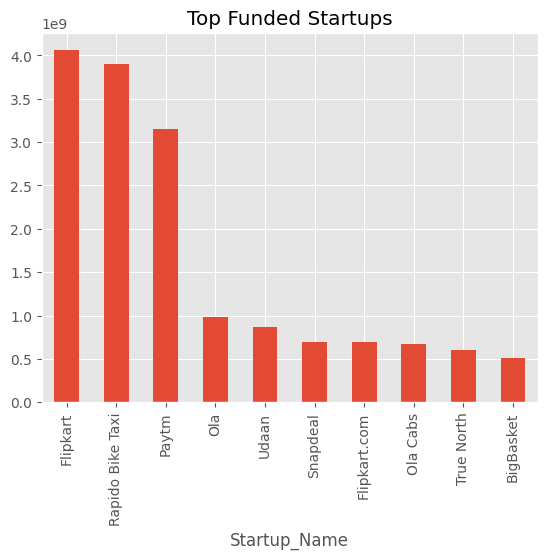

In [ ]:
#barchart
top_startups=df.groupby(
'Startup_Name'
)['Amount']\
.sum()\
.sort_values(
ascending=False
)\
.head(10)

top_startups.plot(kind='bar')
plt.title("Top Funded Startups")
plt.show()

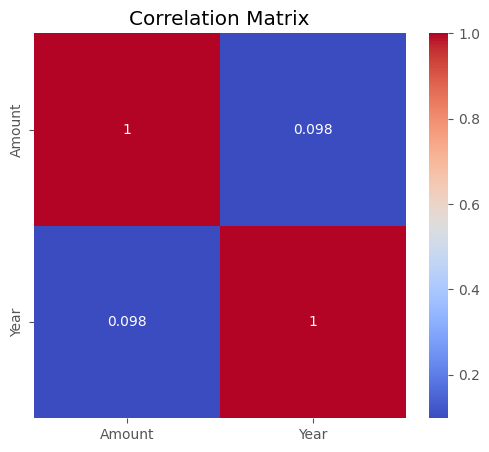

In [ ]:
# final-corelaton matrix
numeric_df = df[['Amount','Year']]
plt.figure(figsize=(6,5))
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title("Correlation Matrix")
plt.show()

In [ ]:
"""    CONCLUSION::

Successfully analyzed startup funding trends in India using EDA techniques.
Identified major startup hubs, leading industries, and active investors.
Found that Private Equity and Seed Funding were the most common funding types.
Observed significant funding growth in certain years, with a few startups receiving exceptionally large investments.
Overall, the analysis provides valuable insights into India's growing startup ecosystem and investment landscape.

"""